# Hito 1: Spotify Playlists

**Pontificia Universidad Catolica de Chile**  
**Curso:** IIC3633 Sistemas Recomendadores  
**Periodo:** Marzo-Julio 2026  
**Integrantes:** Agustin Llambias, Amaya Quero, Larry Uribe

Este notebook ejecuta el pipeline reproducible del Hito 1 usando el dataset Spotify Playlists de Kaggle. Para esta etapa se utiliza una muestra deterministica del 30% de playlists, preservando playlists completas.

In [1]:
from pathlib import Path

DATA_PATH = Path("data/spotify_dataset.csv")
print("Dataset existe:", DATA_PATH.exists())
print("Ruta:", DATA_PATH.resolve())
if DATA_PATH.exists():
    print("Tamano GB:", round(DATA_PATH.stat().st_size / 1024**3, 2))

Dataset existe: True
Ruta: C:\RecSys\Proyecto-RecSys-2026-1\data\spotify_dataset.csv
Tamano GB: 1.1


## Ejecucion del pipeline

El script calcula estadisticas globales del CSV completo con DuckDB, extrae una muestra deterministica del 30% por playlist, evalua tres baselines y genera reportes/figuras.

In [2]:
%run hito1_spotify_baselines.py

[19:31:42] Calculando estadisticas globales del CSV completo


[19:31:48] Cargando muestra deterministica del 30% por playlist


[19:32:00] Calculando estadisticas descriptivas de la muestra


[19:32:08] Construyendo split leave-last-out por playlist


[19:32:11] Evaluando 63,851 playlists


...

[19:32:20] Evaluando baseline: Most Popular


[19:32:21] Evaluando baseline: Playlist Name Popular


[19:32:31] Generando figuras


[19:32:33] Escribiendo reportes



Dataset completo:
rows: 12199339
users: 15889
artists: 271369
tracks: 1854175
items: 2614129
playlists: 225591

Muestra:
rows: 3721218
users: 12745
artists: 150326
tracks: 947293
items: 1273839
playlists: 68012

Evaluacion:
eval_playlists: 63851
catalog_train_items: 1258737

Baselines:
               Modelo  HitRate@10  Precision@10   MAP@10  nDCG@10
               Random    0.000031      0.000003 0.000005 0.000011
         Most Popular    0.001112      0.000111 0.000141 0.000350
Playlist Name Popular    0.011903      0.001190 0.004055 0.005841

Reporte escrito en resultados_hito1_spotify.md
Tiempo total: 51.68 segundos


## Resultados generados

# Resultados preliminares Hito 1 - Spotify Playlists

## Dataset completo

- Registros: 12,199,339
- Usuarios: 15,889
- Artistas: 271,369
- Tracks por nombre: 1,854,175
- Items artista-track: 2,614,129
- Playlists usuario-nombre: 225,591

## Muestra utilizada

Para este Hito 1 se uso una muestra deterministica del 30% de las playlists, preservando playlists completas mediante hashing de `user_id` y `playlistname`. Esto reduce el costo computacional sobre un CSV de 1.18 GB, mantiene reproducibilidad y es suficiente para el objetivo del hito: exploracion preliminar e implementacion de baselines.

- Registros en muestra: 3,721,218
- Usuarios en muestra: 12,745
- Playlists en muestra: 68,012
- Items artista-track en muestra: 1,273,839
- Mediana de canciones por playlist: 16.0
- Promedio de canciones por playlist: 54.71

## Evaluacion

Para cada playlist con al menos 3 canciones, se oculto la ultima cancion como test y se entreno con el resto.

- Playlists evaluadas: 63,851
- Catalogo de entrenamiento: 1,258,737 items

## Baselines

| Modelo | HitRate@10 | Precision@10 | MAP@10 | nDCG@10 |
| --- | ---: | ---: | ---: | ---: |
| Random | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| Most Popular | 0.0011 | 0.0001 | 0.0001 | 0.0004 |
| Playlist Name Popular | 0.0119 | 0.0012 | 0.0041 | 0.0058 |


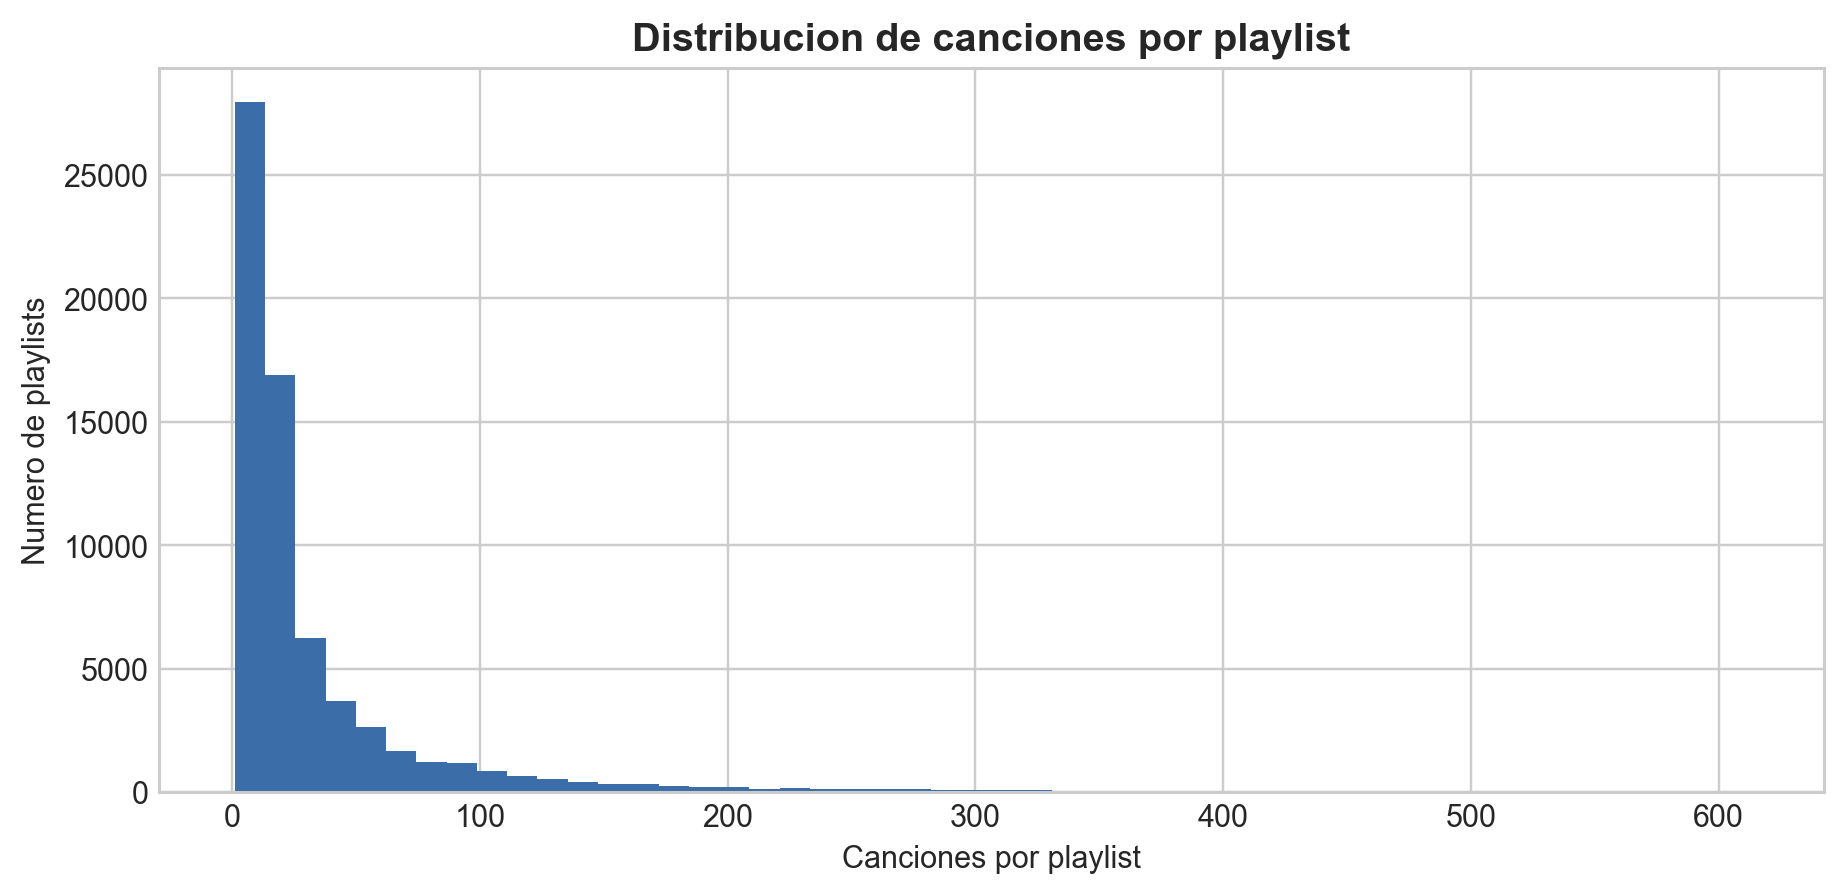

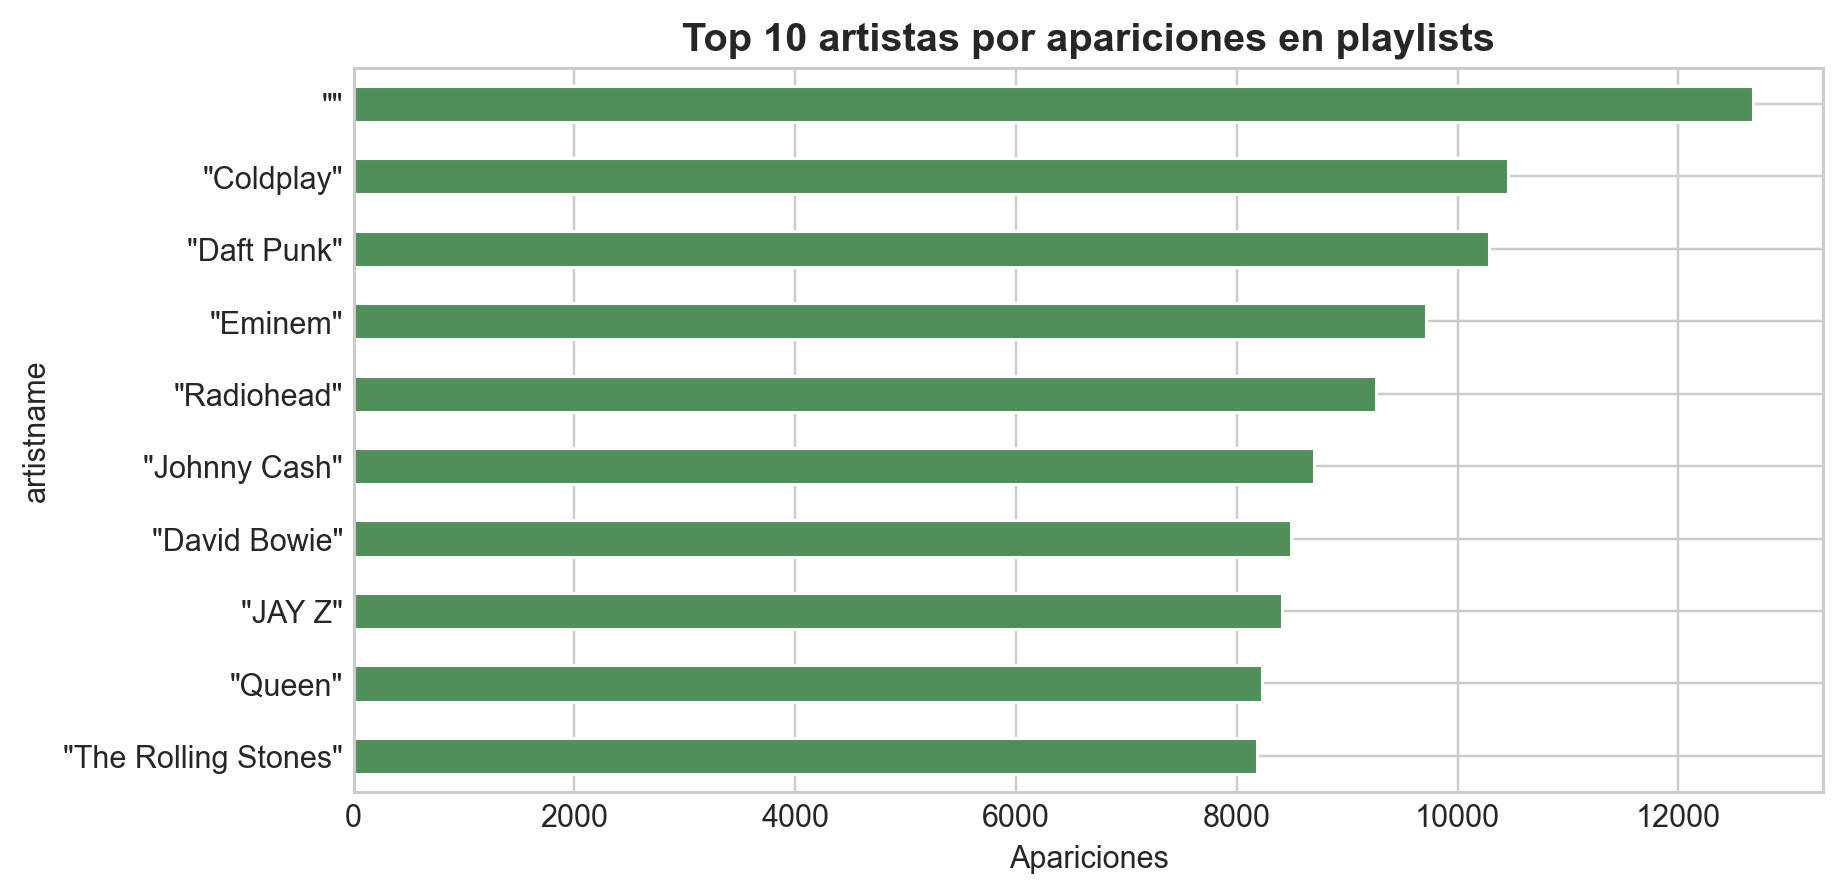

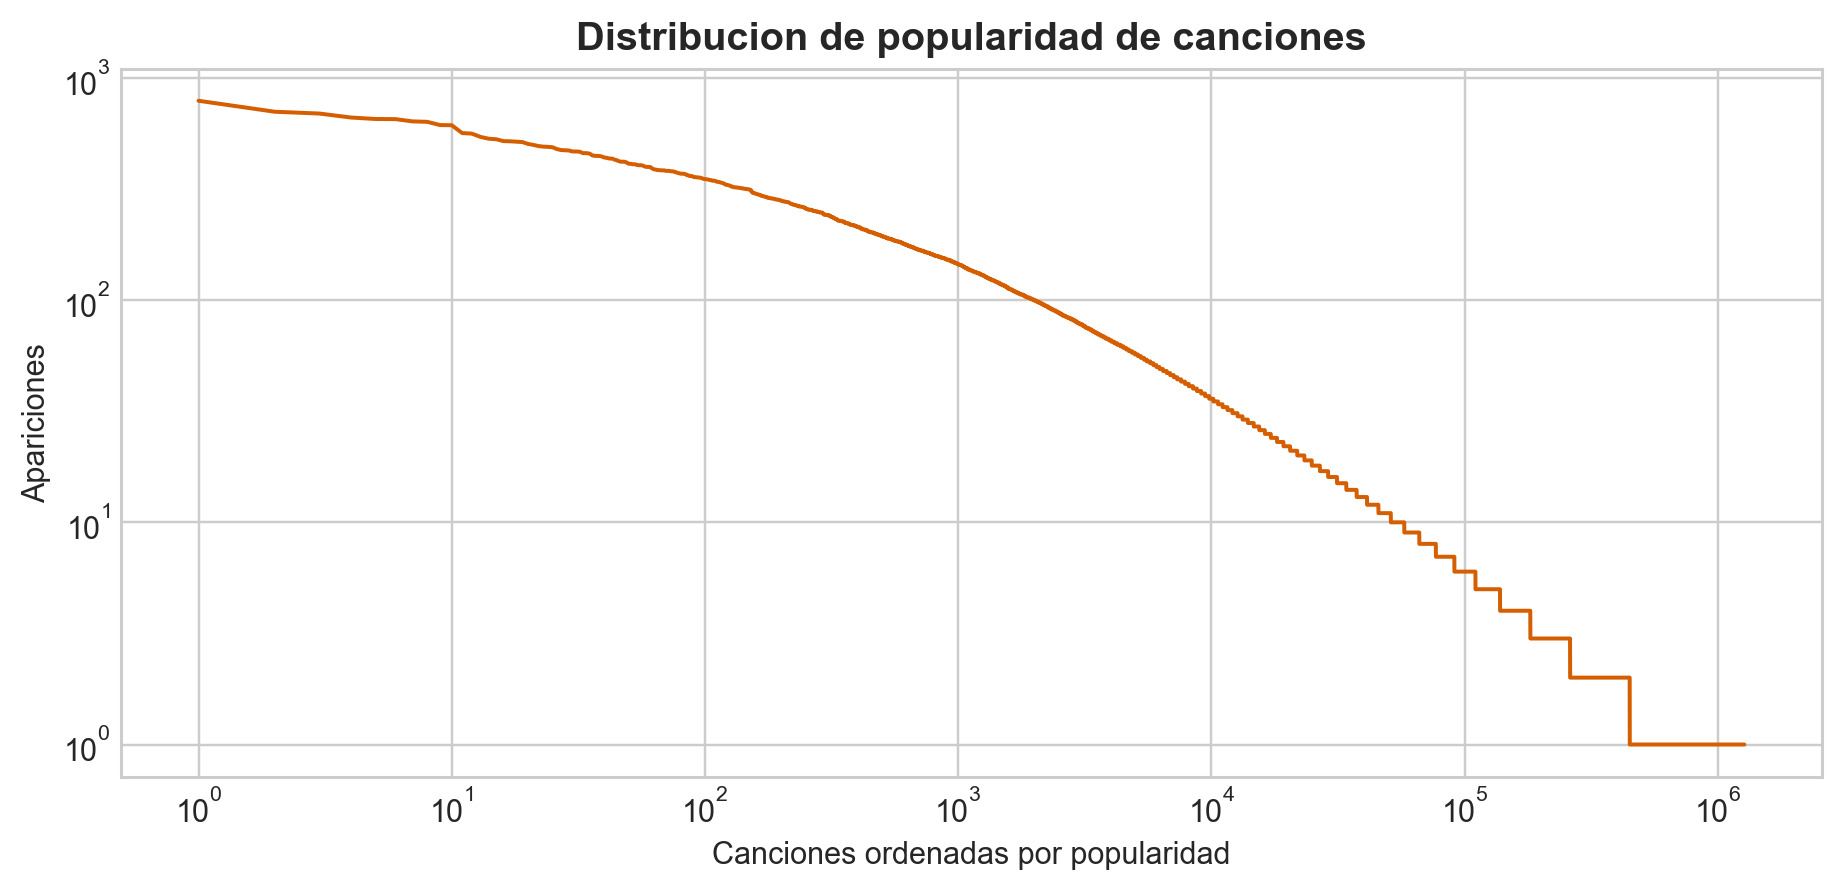

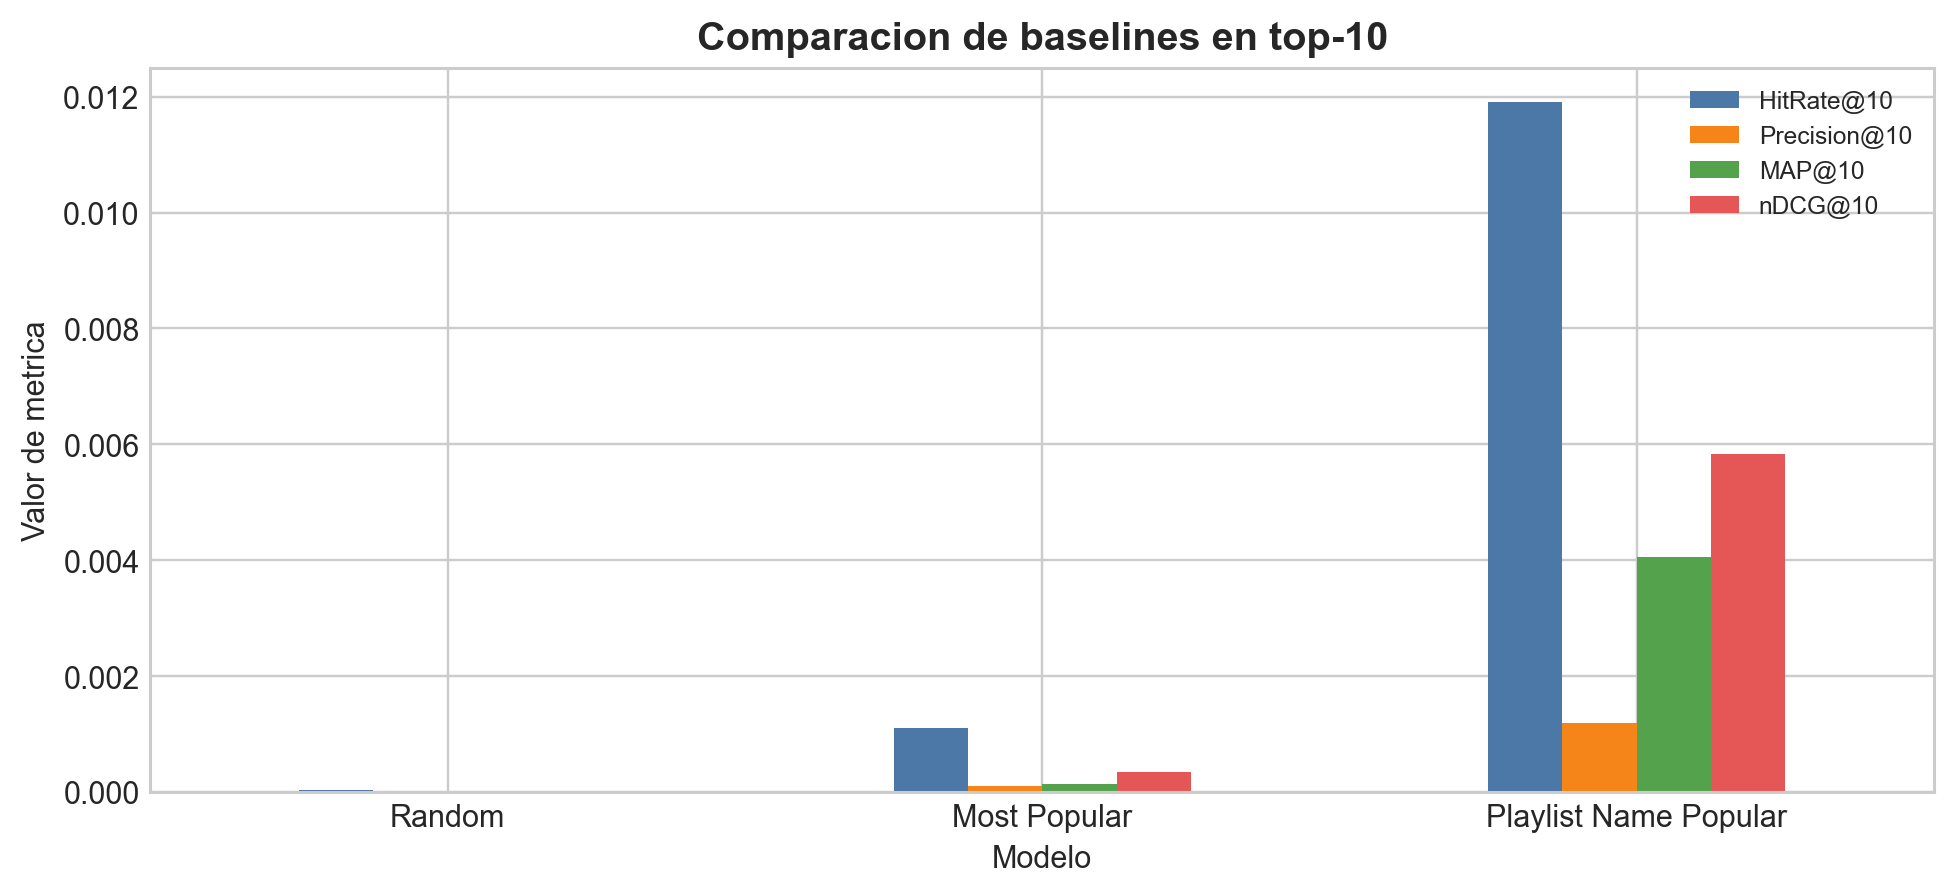

In [3]:
from pathlib import Path
from IPython.display import Markdown, display, Image

report = Path("resultados_hito1_spotify.md")
if report.exists():
    display(Markdown(report.read_text(encoding="utf-8")))

for fig in [
    "figures/spotify_tamano_playlists.png",
    "figures/spotify_top_artistas.png",
    "figures/spotify_distribucion_popularidad.png",
    "figures/spotify_metricas_baselines.png",
]:
    if Path(fig).exists():
        display(Image(filename=fig))